In [1]:
import sys
print("\n".join(sys.path))
sys.path.insert(0, "/teamspace/studios/this_studio/PINNProof/PINNProof/src")
print("\n".join(sys.path))

/teamspace/studios/this_studio
/teamspace/studios/this_studio/PINNProof/PINNProof/examples
/home/zeus/miniconda3/envs/cloudspace/lib/python310.zip
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/lib-dynload

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages
/teamspace/studios/this_studio/PINNProof/PINNProof/src
/teamspace/studios/this_studio
/teamspace/studios/this_studio/PINNProof/PINNProof/examples
/home/zeus/miniconda3/envs/cloudspace/lib/python310.zip
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/lib-dynload

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages


In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, D, P_m, X_d_dash, H, time_tensor,
                 Rs, Re, X_q_dash, Xep, Tdp, Tqp, Efd, Xd, Xq):
        super(SynchronousMachine, self).__init__()
        self.D = D
        self.P_m = P_m
        self.omega_s0 = 0.0
        self.omega_B = 2 * torch.pi * 50
        self.X_d_dash = X_d_dash
        self.H = H
        self.Rs = Rs
        self.Re = Re
        self.X_q_dash = X_q_dash
        self.Xep = Xep
        Z = torch.tensor([[self.Rs, -self.X_q_dash], [self.X_d_dash, self.Rs]])
        self.Z_inverse = torch.linalg.inv(Z)
        self.E_fd = Efd
        self.T_d_dash = Tdp
        self.T_q_dash = Tqp
        self.X_d = Xd
        self.X_q = Xq
        self.time_tensor = time_tensor
        self.V_tensor = None
        self.theta_tensor = None

    def forward(self, t, y):
        delta, omega, E_d_dash, E_q_dash,P_m, V_t,theta_vs  = y
        # V_t = self.get_V(t)
        # theta_vs = self.get_theta(t)
        v1 = E_d_dash - V_t * torch.sin(delta - theta_vs)
        v2 = E_q_dash - V_t * torch.cos(delta - theta_vs)
        I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
        I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
        P_e = E_d_dash * I_d + E_q_dash * I_q + (self.X_q_dash - self.X_d_dash) * I_d * I_q
        ddelta_dt = omega
        domega_dt = (self.omega_B / (2 * self.H)) * (P_m - P_e - self.D * omega)
        # Internal voltages assumed constant
        dE_d_dash_dt = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dE_q_dash_dt = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dP_m = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dV_t = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        d_theta_vs =torch.tensor(0.0, dtype=y.dtype, device=y.device)
        return torch.stack([ddelta_dt, domega_dt, dE_d_dash_dt, dE_q_dash_dt,dP_m, dV_t,d_theta_vs])

    def interface(self, dataset):
            Vs = dataset[:,:,-2]
            th = dataset[:,:, -1]
            delta = dataset[:,:, 0]
            omega = dataset[:,:, 1]
            E_d = dataset[:,:, 2]
            E_q = dataset[:,:, 3]

            # compute currents
            v1 = E_d - Vs * torch.sin(delta - th)
            v2 = E_q - Vs * torch.cos(delta - th)
            I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
            I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
            I_D = I_d * torch.cos(delta - torch.pi/2) - I_q * torch.sin(delta - torch.pi/2)
            I_Q = I_d * torch.sin(delta - torch.pi/2) + I_q * torch.cos(delta - torch.pi/2)
            return I_D, I_Q

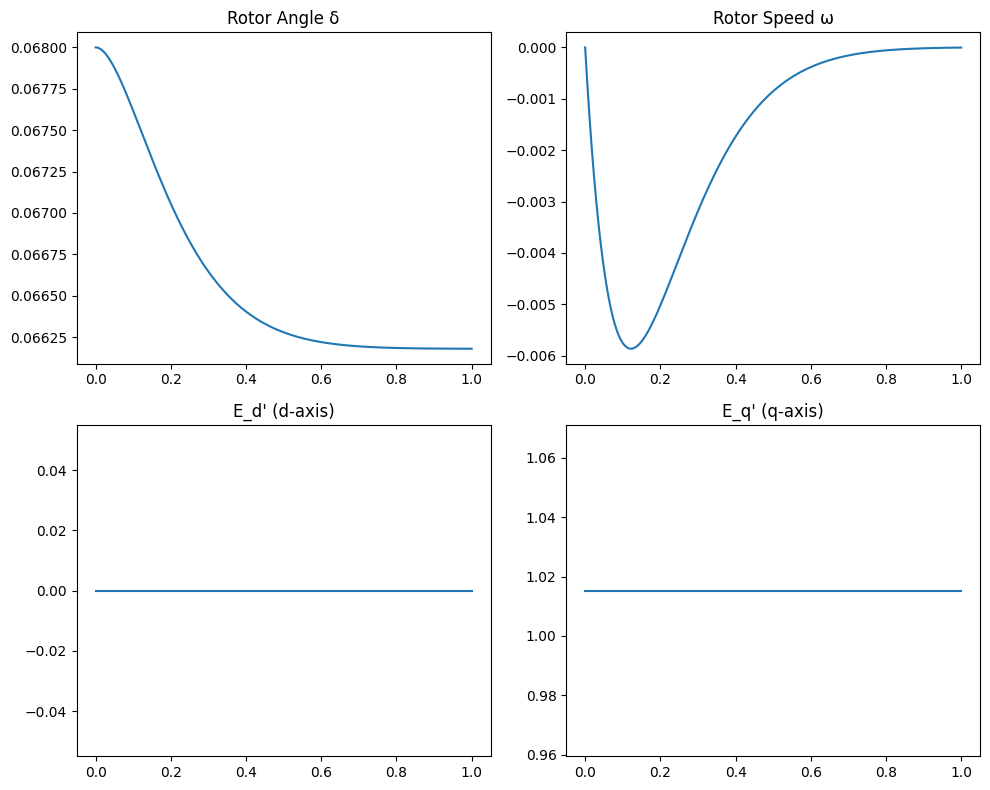

In [3]:
import torch
from torchdiffeq import odeint
from solvers.solver import Solver  # your base classes
from solvers.ODE_conventional import ODE_conventional
# from your_module import SynchronousMachine   # wherever you defined it

# 1) Create a time‐vector and a corresponding “voltage profile” for the machine.
#    Here we just hold Vs = 1.0∠0° constant.
t_final, num_points = 1.0, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs      = torch.ones(num_points)     # pu magnitude
θs      = torch.zeros(num_points)   # pu angle
V_profile = torch.stack((Vs, θs), dim=1)  # shape (num_points, 2)

# 2) Instantiate the machine with your chosen parameters.
#    SynchronousMachine.forward has signature (t, y) → dy/dt,
#    but it needs access to V_profile and t_tensor internally.
params = {
    'D': 2.364, 'P_m': 0.71, 'X_d_dash': 0.0608, 'H': 23.64,
    'Rs': 0.0, 'Re': 0.0, 'X_q_dash': 0.0969, 'Xep': 0.0,
    'Tdp': 8.96, 'Tqp': 0.31, 'Efd': 1.08, 'Xd': 0.146, 'Xq': 0.0969
}
machine = SynchronousMachine(
    params['D'], params['P_m'], params['X_d_dash'], params['H'],
    t_tensor, params['Rs'], params['Re'], params['X_q_dash'], params['Xep'],
    params['Tdp'], params['Tqp'], params['Efd'], params['Xd'], params['Xq']
)
# machine.set_time_tensor(t_tensor)
# machine.set_V_tensor(V_profile)  # (T,1,2) as your Generator4D expects

# 3) Wrap its `forward` as the ODE‐function for your solver.
#    No extra args needed since everything is on `machine` itself
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Pick an initial state [δ₀, ω₀, E′d₀, E′q₀]
x0 = [0.0680, 0.0, 0.0, 1.0153,0.7, 1,0]

# 5) Solve!
t, sol = solver.solve(x0, t_final, num_points)
delta = sol[:,0]; omega = sol[:,1]
E_d = sol[:,2]; E_q = sol[:,3]

# plot all states & currents
fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()
axs[0].plot(t.squeeze(), delta.detach()); axs[0].set_title('Rotor Angle δ')
axs[1].plot(t.squeeze(), omega.detach()); axs[1].set_title('Rotor Speed ω')
axs[2].plot(t.squeeze(), E_d.detach()); axs[2].set_title("E_d' (d-axis)")
axs[3].plot(t.squeeze(), E_q.detach()); axs[3].set_title("E_q' (q-axis)")
# axs[4].plot(t.squeeze(), I_D.detach()); axs[4].set_title('Current I_D')
# axs[5].plot(t.squeeze(), I_Q.detach()); axs[5].set_title('Current I_Q')
plt.tight_layout()
# # plt.show()
# # 6) Extract and plot
# fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# axs = axs.flatten()
# labels = ['δ', 'ω', "E_d'", "E_q'", "E_q''", "E_d''", 'I_D', 'I_Q']
# for i in range(4):
#     axs[i].plot(t.squeeze(), sol[:, i].detach())
#     axs[i].set_ylabel(labels[i])
# # axs[6].plot(time_pts.squeeze(), I_D.detach()); axs[6].set_ylabel('I_D')
# # axs[7].plot(time_pts.squeeze(), I_Q.detach()); axs[7].set_ylabel('I_Q')
# for ax in axs:
#     ax.set_xlabel('Time [s]')
# plt.tight_layout()
# plt.show()


In [4]:
V_profile.shape

torch.Size([1000, 2])

In [5]:
# # ic_ranges = {
# #   'delta': (-0.1, 0.1),
# #   'omega': (-0.2, 0.2),
# #   'E_d_dash': (0.0, 0.1),
# #   'E_q_dash': (0.9, 1.1),
# #   'V_t': (0.9, 1.1),
# #   'theta_vs': (0.9, 1.1),
# # }
# ic_ranges = {
#   'delta': (-0.1, 0.1),
#   'omega': (-0.2, 0.2),
#   'E_d_dash': (0.0, 0.0),
#   'E_q_dash': (1.0,1.0),
#   'P_m': (0.7,0.7),
#   'V_t': (0.9, 1.1),
#   'theta_vs': (0.9, 1.1),
# }

# t, data, ics = solver.generate_dataset(
#     ic_ranges=ic_ranges,
#     num_ic=100,
#     t_final=t_final,
#     num_points=num_points
#     # save_path='datasets/sync_machine.npz'
# )
import torch

# 1) Your dict of ranges (in the order your state vector expects)
ic_ranges = {
  'delta':     (-0.1,  0.1),
  'omega':     (-0.2,  0.2),
  'E_d_dash':  ( 0.0,  0.0),
  'E_q_dash':  ( 1.0,  1.0),
  'P_m':       ( 0.7,  0.7),
  'V_t':       ( 0.9,  1.1),
  'theta_vs':  ( 0.9,  1.1),
}

# 2) Turn it into a (D,2) tensor in the same order
#    *Make sure this ordering matches exactly the order your solver
#     expects its initial‐condition vector y0 = [delta, omega, …, theta_vs].*
keys = ['delta','omega','E_d_dash','E_q_dash','P_m','V_t','theta_vs']
bounds = torch.tensor([ic_ranges[k] for k in keys], dtype=torch.float32)

# 3) Call generate_dataset
num_ic     = 10
t_final    = 1.0
num_points = 100

ic_tensor, traj_tensor = solver.generate_dataset(
    ic_ranges=bounds,
    num_ic=num_ic,
    t_final=t_final,
    num_points=num_points,
    sampling='random',   # or 'random'
    device='cpu',
    save_path=None       # or a path to save .pt files
)

print("Initial conditions shape:", ic_tensor.shape)       # [100, 7]
print("Trajectories shape:",      traj_tensor.shape)     # [100,1000,7]


/teamspace/studios/this_studio/PINNProof/PINNProof/src/solvers/ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


Initial conditions shape: torch.Size([10, 7])
Trajectories shape: torch.Size([10, 100, 7])


In [ ]:
#transform dataset to the right input we want it
# dataset should have the dimensions of [10,7,100]
def create_data(dataset):
    data=dataset
    x_train_list = torch.tensor(())
    y_train_list = torch.tensor(())
    for training_sample in data:
        training_sample = torch.tensor(training_sample, dtype=torch.float32)
        y_train = training_sample[1:].T.clone().detach().requires_grad_(True)
        x_train = training_sample.T
        x_train[:,1:]=x_train[0][1:]
        #discrard the first row of x_train and y_train as they are the same
        #x_train = x_train[1:]
        #y_train = y_train[1:]
        x_train = x_train.clone().detach().requires_grad_(True)
        x_train_list = torch.cat((x_train_list, x_train), 0)
        y_train_list = torch.cat((y_train_list, y_train), 0)
    return x_train_list, y_train_list

In [7]:
from pretrained_models.architectures import Network
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof")  
print("After Changing:", os.getcwd())

After Changing: /teamspace/studios/this_studio/PINNProof/PINNProof


In [8]:
model=Network(input_size=8, hidden_size=64, output_size=4, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "examples/pretrained_models/SM4_P_LBFGS_seed7.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>